# CS 6220 - Data Mining Techniques - Homework 1  
Name : Shashank Jajimoggala   
NUID : 002570569

Task : Using the Iris dataset, build a scikit-learn pipeline that predicts the species from the four flower measurements. Two classifiers are compared: logistic regression and a decision tree.

## 1. Import required packages

In [1]:
# Step 1: Import required packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix

## 2: Load the Iris dataset from the raw UCI file.

In [2]:
# Step 2: Load the Iris dataset from the raw UCI file.
# Source: https://archive.ics.uci.edu/dataset/53/iris
# The file has no header row, so column names are supplied explicitly.
# Column order is documented in iris.names.

COLUMN_NAMES = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
    "species",
]

iris_df = pd.read_csv(
    "data/homework_1/iris/iris.data",
    header=None,
    names=COLUMN_NAMES,
)

print(f"Shape : {iris_df.shape}")
iris_df.head()

Shape : (150, 5)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Inspect the data

Three checks before modelling: column types and missing values, feature distributions, and class balance. 

In [3]:
# Step 3: Inspect the data — types, missing values, class balance, and distributions.

iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   species          150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
iris_df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris_df["species"].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

**Observations**

- 150 rows, 5 columns, no missing values. Four numeric features, one string label.
- Classes are perfectly balanced at 50 each. Accuracy is therefore a reasonable 
  headline metric; on an imbalanced dataset it would not be.
- Feature spreads differ: petal length has a standard deviation of 1.76 cm against 
  0.43 cm for sepal width, a ratio of roughly 4:1. This matters for any model that 
  combines features into a single distance or weighted sum.

## 4. Visualise feature relationships

A scatterplot matrix of all feature pairs, coloured by species, to see which features 
separate the classes before any model is fitted.

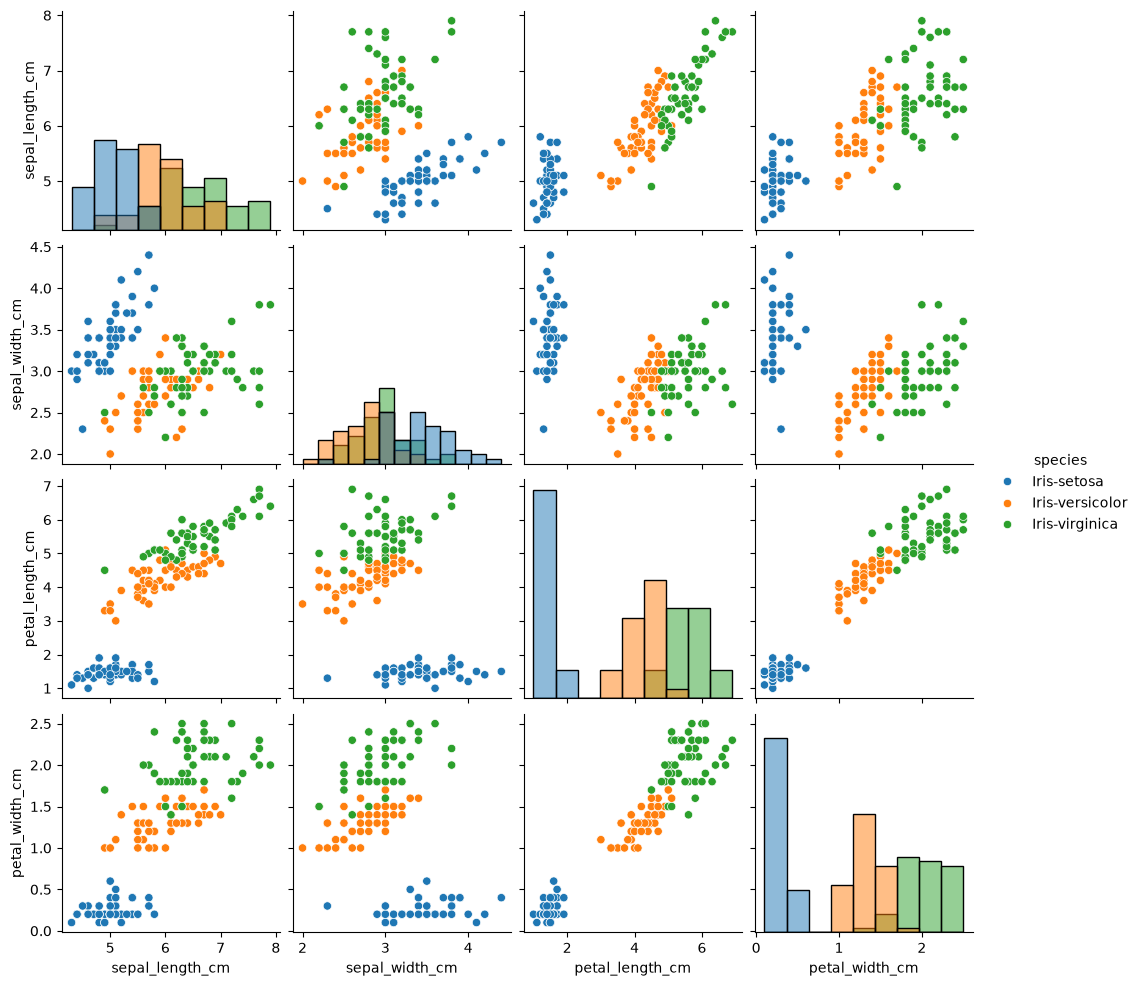

In [6]:
# Step 4: Scatterplot matrix — every feature against every other, coloured by species.

sns.pairplot(iris_df, hue="species", diag_kind="hist")
plt.show()

**Observations from the scatterplot matrix**

- *Iris-setosa* forms a distinct cluster in every panel, with no overlap against the other two species. The separation is clearest in any panel involving a petal measurement, where a visible gap divides setosa from the rest.
- *Iris-versicolor* and *Iris-virginica* form adjacent clusters. Using petal length and petal width they are almost separable, with only a few points falling across the boundary between them.
- The overlap is substantially worse in sepal length vs. sepal width, where the two species are heavily intermixed. The petal measurements are the more discriminative features.
- Petal length and petal width are strongly correlated with each other, so the two carry largely overlapping information.

**Prediction:** setosa should be classified perfectly. Any misclassifications will be between versicolor and virginica, and should number only a few.

## 5. Train/test split

The data is split 80/20 into training and test sets. The raw file is sorted by species, so shuffling is essential — an unshuffled tail split would produce a test set containing a single class. `train_test_split` shuffles by default; `stratify` additionally guarantees the 50/50/50 class proportions are preserved in both splits, which matters when the test set holds only 30 rows. `random_state` is fixed so the split is reproducible across runs.

In [7]:
# Step 5: Separate features from the label, then split 80/20.

FEATURE_COLUMNS = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
]
LABEL_COLUMN = "species"

X = iris_df[FEATURE_COLUMNS]
y = iris_df[LABEL_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")
print("\nTest set class balance:")
print(y_test.value_counts())

Train: 120 rows
Test:  30 rows

Test set class balance:
species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## 6. Build the pipelines

Two models are compared, each wrapped in a `Pipeline`.

**Logistic regression** combines all four features into a weighted sum, so the relative magnitude of each feature affects the fit. With petal length spread roughly four times wider than sepal width (std 1.76 vs 0.43 cm), the features are standardised first. Scaling also helps the solver converge.

**Decision tree** splits on one feature at a time, comparing it against a threshold. 
Standardising preserves the ordering of values within a feature, so every split available before scaling has an exact equivalent after — scaling cannot change the tree that gets learned. No scaler is used.

Using `Pipeline` for both keeps the fit/predict interface identical, and ensures the scaler learns its mean and standard deviation from training data only. Fitting a scaler on the full dataset before splitting would leak test-set statistics into training.

In [8]:
# Step 6: Construct both pipelines.

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42)),
])

tree_pipeline = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=42))
])

logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The

In [9]:
tree_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left and

## 7. Train the models

Both pipelines are fitted on the training set only. Training time is measured with `perf_counter`.

Note that on 150 rows both models fit in single-digit milliseconds, so these timings are dominated by Python overhead rather than by the learning algorithms themselves.

In [10]:
# Step 7: Fit both pipelines, timing each.

start = perf_counter()
logreg_pipeline.fit(X_train, y_train)
logreg_train_time = perf_counter() - start

start = perf_counter()
tree_pipeline.fit(X_train, y_train)
tree_train_time = perf_counter() - start

print(f"Logistic regression training time: {logreg_train_time * 1000:.3f} ms")
print(f"Decision tree training time:       {tree_train_time * 1000:.3f} ms")

Logistic regression training time: 17.814 ms
Decision tree training time:       4.558 ms


**Observation: repeated runs give different timings**

Re-running the training cell produced substantially faster times than the first run:

| Run | Logistic regression | Decision tree |
|---|---|---|
| First  | 47.431 ms | 4.042 ms |
| Second |  7.852 ms | 2.341 ms |

The first call is roughly 6x slower for logistic regression and 1.7x slower for the decision tree. This is warm-up cost, not variation in the learning itself — the first `fit` pays one-time overhead that later calls do not: scikit-learn lazily imports solver code, and the underlying numerical libraries (BLAS) initialise and spin up worker threads on first use. Logistic regression is affected more because it runs an iterative numerical solver with more machinery behind it, while the decision tree is largely direct loops over the data.

A single measurement at this scale is therefore not a reliable estimate of training cost. The cell below re-fits each pipeline ten times and reports both the first run and the mean of the remaining runs.

In [11]:
# Step 7b: Repeated timing. A single measurement at millisecond scale is dominated
# by one-time warm-up costs (lazy imports, BLAS initialisation), so both pipelines
# are re-fitted several times and the mean of the warm runs is reported.

N_RUNS = 100

def time_fit(pipeline, X, y, n_runs=N_RUNS):
    """Fit `pipeline` n_runs times, returning (first_run_seconds, mean_of_remaining)."""
    timings = []
    for _ in range(n_runs):
        start = perf_counter()
        pipeline.fit(X, y)
        timings.append(perf_counter() - start)
    return timings[0], sum(timings[1:]) / len(timings[1:])

logreg_cold, logreg_warm = time_fit(logreg_pipeline, X_train, y_train)

print(f"Logistic regression — first run: {logreg_cold * 1000:.3f} ms")
print(f"Logistic regression — warm mean: {logreg_warm * 1000:.3f} ms")

tree_cold, tree_warm = time_fit(tree_pipeline, X_train, y_train)

print(f"Decision tree  — first run: {tree_cold * 1000:.3f} ms")
print(f"Decision tree  — warm mean: {tree_warm * 1000:.3f} ms")

Logistic regression — first run: 9.945 ms
Logistic regression — warm mean: 3.516 ms
Decision tree  — first run: 1.162 ms
Decision tree  — warm mean: 1.068 ms


## 8. Evaluate on the test set

Both fitted pipelines predict on the 30 held-out test rows. These rows were not seen during training, so accuracy here estimates how the models generalise rather than how well they memorised.

Prediction is timed with the same repeated-run approach used for training, for the same reason: a single pass over 30 rows completes too quickly for one measurement to be meaningful.

In [12]:
# Step 8: Timing helper for prediction. Mirrors time_fit, but predict() returns the
# predictions themselves, so those are returned alongside the timings.

def time_predict(pipeline, X, n_runs=N_RUNS):
    """Predict n_runs times, returning (predictions, first_run_seconds, mean_of_remaining)."""
    timings = []
    for _ in range(n_runs):
        start = perf_counter()
        predictions = pipeline.predict(X)
        timings.append(perf_counter() - start)
    return predictions, timings[0], sum(timings[1:]) / len(timings[1:])


logreg_predictions, logreg_predict_cold, logreg_predict_warm = time_predict(
    logreg_pipeline, X_test
)

print(f"Logistic regression — first run: {logreg_predict_cold * 1000:.3f} ms")
print(f"Logistic regression — warm mean: {logreg_predict_warm * 1000:.3f} ms")


tree_predictions, tree_predict_cold, tree_predict_warm = time_predict(
    tree_pipeline, X_test
)

print(f"Decision tree — first run: {tree_predict_cold * 1000:.3f} ms")
print(f"Decision tree — warm mean: {tree_predict_warm * 1000:.3f} ms")

Logistic regression — first run: 1.667 ms
Logistic regression — warm mean: 0.544 ms
Decision tree — first run: 0.453 ms
Decision tree — warm mean: 0.397 ms


**Observation: measurement noise at sub-millisecond scale**

An initial run with `n_runs=10` gave a warm mean of 2.262 ms for decision tree prediction against 0.715 ms for logistic regression — the tree three times slower. 
This contradicts the mechanism: predicting with a fitted tree is a handful of threshold comparisons per row, while logistic regression performs a scaling transform and a matrix multiplication.

Suspecting the measurement rather than the algorithms, `n_runs` was increased to 100.
 
The ordering reversed: 0.406 ms for the tree against 0.616 ms for logistic regression, matching expectation. 

The earlier figure was an artefact of averaging over too few samples, where a single scheduling pause or garbage collection cycle dominates a sub-millisecond measurement.

In [13]:
# Step 9: Accuracy on the held-out test set.

logreg_accuracy = accuracy_score(y_test, logreg_predictions)
tree_accuracy = accuracy_score(y_test, tree_predictions)

print(f"Logistic regression accuracy: {logreg_accuracy:.4f}")
print(f"Decision tree accuracy:       {tree_accuracy:.4f}")

Logistic regression accuracy: 0.9333
Decision tree accuracy:       0.9333


In [14]:
# Step 10: Confusion matrices. Rows are true classes, columns are predicted.

class_labels = sorted(y.unique())

print("Logistic regression:")
print(pd.DataFrame(
    confusion_matrix(y_test, logreg_predictions, labels=class_labels),
    index=[f"true_{c}" for c in class_labels],
    columns=[f"pred_{c}" for c in class_labels],
))

print("\nDecision Tree:")
print(pd.DataFrame(
    confusion_matrix(y_test, tree_predictions, labels=class_labels),
    index=[f"true_{c}" for c in class_labels],
    columns=[f"pred_{c}" for c in class_labels],
))


Logistic regression:
                      pred_Iris-setosa  pred_Iris-versicolor  \
true_Iris-setosa                    10                     0   
true_Iris-versicolor                 0                     9   
true_Iris-virginica                  0                     1   

                      pred_Iris-virginica  
true_Iris-setosa                        0  
true_Iris-versicolor                    1  
true_Iris-virginica                     9  

Decision Tree:
                      pred_Iris-setosa  pred_Iris-versicolor  \
true_Iris-setosa                    10                     0   
true_Iris-versicolor                 0                     9   
true_Iris-virginica                  0                     1   

                      pred_Iris-virginica  
true_Iris-setosa                        0  
true_Iris-versicolor                    1  
true_Iris-virginica                     9  


In [15]:
# Do the two models make the same predictions, or just the same number of errors?
comparison = pd.DataFrame({
    "true": y_test.values,
    "logreg": logreg_predictions,
    "tree": tree_predictions,
})
disagreements = comparison[comparison["logreg"] != comparison["tree"]]
print(f"Rows where the models disagree: {len(disagreements)}")
disagreements

Rows where the models disagree: 0


,true,logreg,tree


**Observation: the two models are indistinguishable on this split**

Both pipelines achieved 0.9333 accuracy (28/30), and their confusion matrices are 
identical. Comparing predictions row by row showed zero disagreements — the models 
made the same call on every test flower.

Both errors were between versicolor and virginica, one in each direction; setosa was 
classified perfectly. This matches the prediction made from the scatterplot matrix 
before any model was fitted.

The agreement reflects the geometry of the data rather than any similarity between 
the algorithms. Setosa is separated from the other two classes by a wide margin, and 
the versicolor/virginica boundary is crossed by only a few points, so a linear 
boundary and a set of axis-aligned splits land in effectively the same place. On this 
split, accuracy cannot distinguish the two models; selection would have to rest on 
other criteria such as runtime or interpretability.

With only 30 test rows, a single misclassification moves accuracy by 3.33 percentage 
points. This estimate is correspondingly coarse, and the agreement observed here is a 
property of this particular split rather than a general result.

## 11. Hyperparameter exploration

Hyperparameters are values set before training that control how learning happens, as distinct from parameters learned during `fit`. For logistic regression, `C` controls regularisation strength — inversely, so smaller values penalise large coefficients more heavily and push toward simpler boundaries. For the decision tree, `max_depth` caps how many levels of splits the tree may grow.

Each candidate value is scored using 5-fold cross-validation **on the training set only**. Using test accuracy to select a hyperparameter would let the test set influence the model, making the final accuracy an optimistic estimate rather than a measure of generalisation. The test set is used once, at the end, on the chosen configuration.

In [16]:
# Step 11: Sweep C for logistic regression, scored by 5-fold cross-validation on the
# training set only. The test set is not touched here.

C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

logreg_sweep = []
for c in C_VALUES:
    candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(C=c, random_state=42)),
    ])
    scores = cross_val_score(candidate, X_train, y_train, cv=5)
    logreg_sweep.append({
        "C": c,
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std(),
    })

logreg_sweep_df = pd.DataFrame(logreg_sweep)
logreg_sweep_df

,C,mean_cv_accuracy,std_cv_accuracy
0,0.001,0.833333,0.026352
1,0.010,0.875000,0.026352
2,0.100,0.925000,0.040825
3,1.000,0.958333,0.026352
4,10.000,0.966667,0.031180
5,100.000,0.966667,0.031180


## 12. Sweep max_depth for the decision tree

In [17]:
# Step 12: Sweep max_depth for the decision tree, same 5-fold CV on training data only.
# None means unrestricted — the tree grows until leaves are pure.

MAX_DEPTHS = [1, 2, 3, 4, 5, 6, None]

tree_sweep = []
for depth in MAX_DEPTHS:
    candidate = Pipeline([
        ("classifier", DecisionTreeClassifier(max_depth=depth, random_state=42)),
    ])
    scores = cross_val_score(candidate, X_train, y_train, cv=5)
    tree_sweep.append({
        "max_depth": depth,
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std(),
    })

tree_sweep_df = pd.DataFrame(tree_sweep)
tree_sweep_df

,max_depth,mean_cv_accuracy,std_cv_accuracy
0,1.0,0.666667,0.000000
1,2.0,0.925000,0.031180
2,3.0,0.933333,0.020412
3,4.0,0.941667,0.020412
4,5.0,0.941667,0.020412
5,6.0,0.941667,0.020412
6,NaN,0.941667,0.020412


**Hyperparameter findings**

*Logistic regression:* accuracy rises from 0.833 at C=0.001 to a plateau of 0.967 at 
C=10 and above. Differences among C=1, 10, and 100 are smaller than the across-fold 
standard deviation (~0.03) and are not meaningful; the default C=1.0 is a reasonable 
choice. Only strong regularisation materially hurts.

*Decision tree:* depth 1 scores exactly 0.6667 with zero variance across folds. This 
follows from the structure — a single split produces two leaves, so one of the three 
classes cannot be predicted at all, and the failure is identical in every fold. Depth 
2 makes all three classes reachable and accuracy jumps to 0.925. Performance plateaus 
at depth 4 (0.9417), with depths 5, 6, and unrestricted giving identical scores: the 
additional levels fit fold-specific noise without improving generalisation. 
`max_depth=4` is preferred over an unrestricted tree — equal accuracy, fewer nodes, 
and a model small enough to inspect directly.

*Comparison:* the plateau values (0.967 vs 0.942) differ by less than the standard 
deviations involved, so cross-validation does not separate the two models either.

All selection was done by cross-validation on the training set. The test set was used 
once, on the default configurations reported in section 9.

## 13. Conclusion

**What was built**

Two scikit-learn pipelines were trained to predict iris species from four flower 
measurements. The logistic regression pipeline includes a `StandardScaler`, because 
that model adds the four features together into a single weighted sum, so a feature 
with a wider numeric range carries more influence. Petal length varies about four 
times as much as sepal width, so the features are put on a common scale first. The 
decision tree pipeline has no scaler: it looks at one feature at a time and compares 
it against a threshold, and scaling does not change the order of values within a 
feature, so it cannot change which splits the tree picks.

**Results**

Both models scored 0.9333 on the 30 test flowers — 28 correct out of 30. Their 
confusion matrices are identical, and comparing predictions row by row showed the two 
models agreed on every single test flower. All errors were between versicolor and 
virginica, one in each direction, and setosa was classified perfectly. This is what 
the scatterplot matrix suggested before any model was trained: setosa sits apart from 
the other two, while versicolor and virginica sit next to each other with a few points 
near the boundary.

**Speed**

Averaged over 100 runs, the decision tree was faster at both stages: 0.943 ms to train 
against 2.714 ms for logistic regression, and 0.402 ms to predict against 0.698 ms. 
These timings needed care. An earlier attempt averaging only 10 runs suggested the 
tree was three times *slower* at prediction, which did not match how the two 
algorithms work. Increasing to 100 runs reversed the result, showing the first figure 
was measurement noise rather than a real difference.

**Which model to choose**

Accuracy cannot separate these two models here, so the choice rests on other things. 
The decision tree is faster, needs no scaling step, and can be read directly as a 
flowchart of yes/no questions. Logistic regression gives probability estimates and 
coefficients showing how much each measurement pushes toward each species. For this 
dataset the decision tree is the simpler choice, mainly because a model you can read 
end to end is worth more than one you cannot when both are equally accurate.

**Limitations**

The test set holds only 30 flowers, so one misclassification moves accuracy by 3.33 
percentage points. A single 80/20 split with a fixed random seed gives one estimate, 
and a different seed would likely give a different number. The finding that the two 
models agree completely applies to this split and should not be read as a general 
result. Cross-validation across several splits would give a more reliable comparison.